In [1]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import iefc

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307


/opt/conda/envs/km310env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import deepdish!
Could not import ray. Parallelized model unavailble.


In [2]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

date = 20250416
date = 20250418
data_path = scoob_llowfsc.path/'exp-data'
exp_path = data_path/f'exp-{date}'
iefc_data_path = data_path/f'exp-{today}'/'iefc'
iefc_telem_path = iefc_data_path/'raw-telem'
iefc_unpacked_path = iefc_data_path/'unpacked-telem'
llowfsc_data_path = data_path/f'exp-{today}'/'llowfsc'
llowfsc_telem_path = llowfsc_data_path/'raw-telem'
llowfsc_unpacked_path = llowfsc_data_path/'unpacked-telem'

camlo_ref_name = 'camlo_ref_0'
camlo_ref_offset_name = 'camlo_ref_offset'

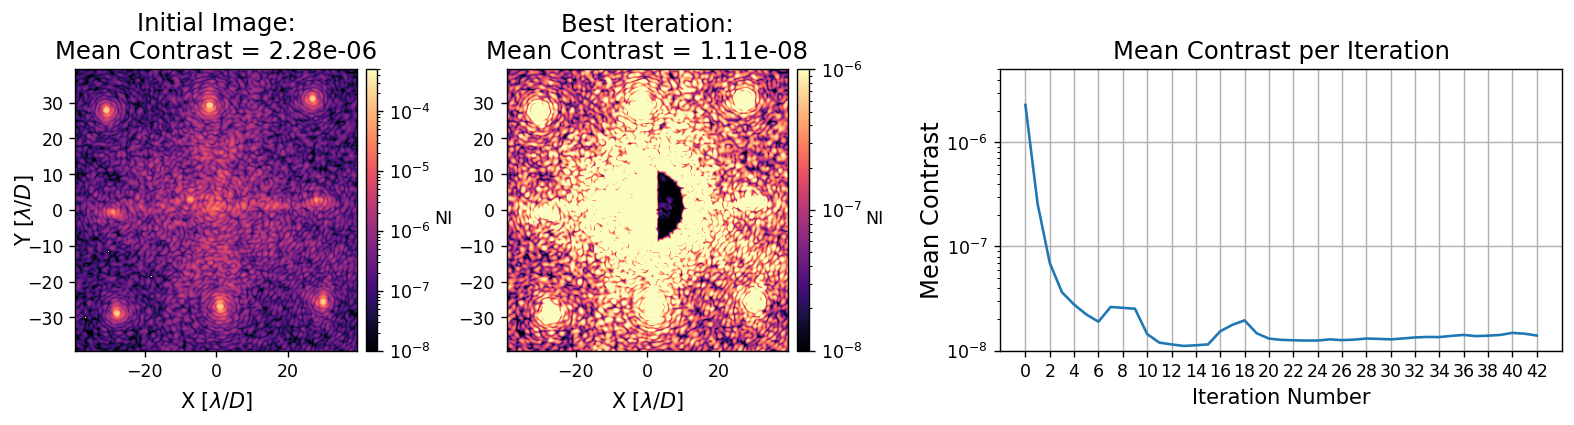

In [3]:
iefc_data = utils.load_pickle(iefc_data_path/'iefc_run_right.pkl')
control_mask = iefc_data['control_mask']

iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-8, im2vmax=1e-6, 
    vmin=1e-8, vmax=5e-6,
)

In [14]:
camsci_data_fnames = telem.get_fnames(iefc_data_path/'camsci_ims_20250418*.fits')
len(camsci_data_fnames), camsci_data_fnames

(12,
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_20250418100812.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_20250418101839.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_20250418102905.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_20250418103933.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_20250418105000.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_20250418110026.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_20250418111052.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_20250418112119.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/ex

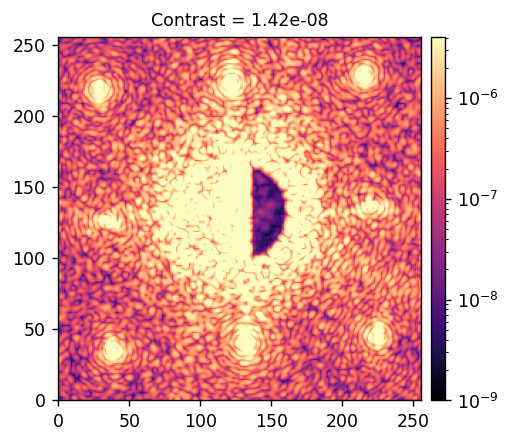

In [13]:
time_series_ims = []
start_times = []
for i in range(len(camsci_data_fnames)):
    time_series_ims.append(utils.load_fits( camsci_data_fnames[i] ))
    start_times.append( camsci_data_fnames[i][-19:-5] )
time_series_ims = xp.array(time_series_ims)
series_start = start_times[0]

mean_im = xp.mean(time_series_ims, axis=(0, 1))
mean_contrast = xp.mean(mean_im[control_mask])

utils.imshow(
    [mean_im],
    titles=[f'Contrast = {mean_contrast:.2e}'],
    norms=[LogNorm(1e-9)],
)


In [15]:
series_start

'20250418100812'

In [16]:
series_times = []
series_start_times = []
series_contrasts = []

for i in range(len(start_times)):
    t_hr = float(start_times[i][-6:-4])
    t_min = float(start_times[i][-4:-2])
    t_sec = float(start_times[i][-2:])
    series_start_times.append( 3600*t_hr + 60*t_min + t_sec ) 
    # print(t_hr, t_min, t_sec)
    print(series_start_times[i])
    # series_times.append(  )
    series_contrasts.append( xp.mean(time_series_ims[i, :, control_mask], axis=0) )

series_start_times = np.array( series_start_times )
series_start_times -= series_start_times[0]
print(series_start_times/60)
series_contrasts = xp.array(series_contrasts)

36492.0
37119.0
37745.0
38373.0
39000.0
39626.0
40252.0
40879.0
41506.0
42133.0
42760.0
43386.0
[  0.          10.45        20.88333333  31.35        41.8
  52.23333333  62.66666667  73.11666667  83.56666667  94.01666667
 104.46666667 114.9       ]


In [32]:
series_contrasts[0].shape

(120,)

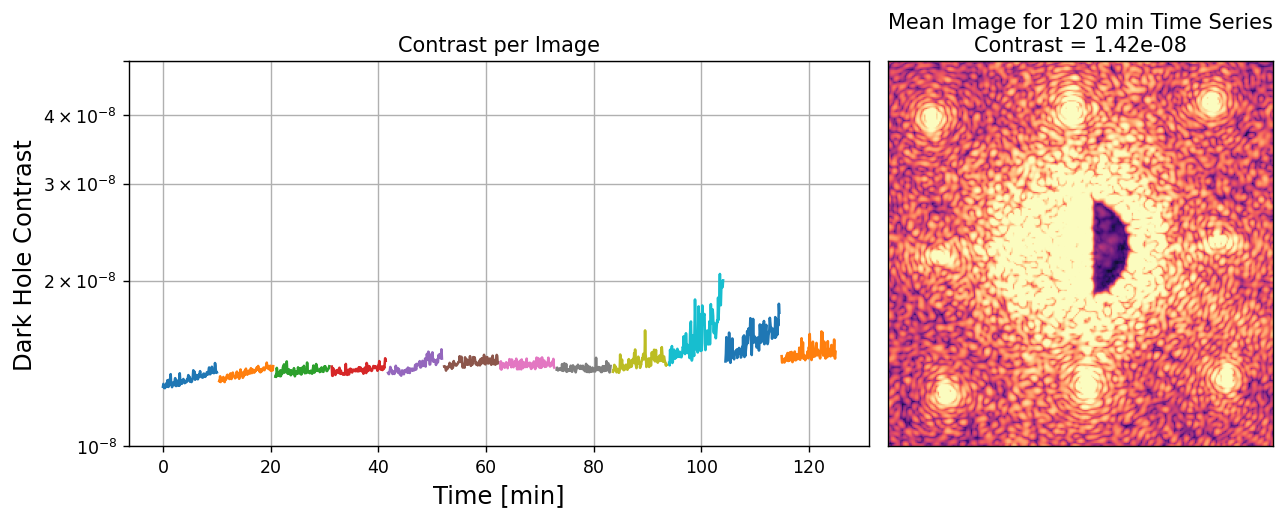

In [21]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4), dpi=125, gridspec_kw={'width_ratios': [1.75, 1], })

vmin = 1e-8
vmax = 5e-8

time_steps = np.linspace(0, 10, time_series_ims.shape[1])
for i in range(len(start_times)):
    axs[0].semilogy(time_steps + series_start_times[i]/60, ensure_np_array(series_contrasts[i]))
axs[0].set_ylim(vmin, vmax)
axs[0].set_yticks(np.linspace(vmin, vmax, 5))
axs[0].set_ylabel('Dark Hole Contrast', fontsize=14)
axs[0].set_xlabel('Time [min]', fontsize=14)
axs[0].grid()
axs[0].set_title('Contrast per Image')

axs[1].imshow(ensure_np_array(mean_im), norm=LogNorm(1e-9), cmap='magma')
axs[1].set_title(f'Mean Image for 120 min Time Series\nContrast = {mean_contrast:.2e}')
axs[1].set_xticks([])
axs[1].set_yticks([])

plt.subplots_adjust(
    wspace=0.0,
)

# Aanlyze with and without reference offset data.

In [22]:
camsci_data_fnames = telem.get_fnames(iefc_data_path/'camsci_ims_without_ref_offset*.fits')
len(camsci_data_fnames), camsci_data_fnames

(1,
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418/iefc/camsci_ims_without_ref_offset_20250418122548.fits'])

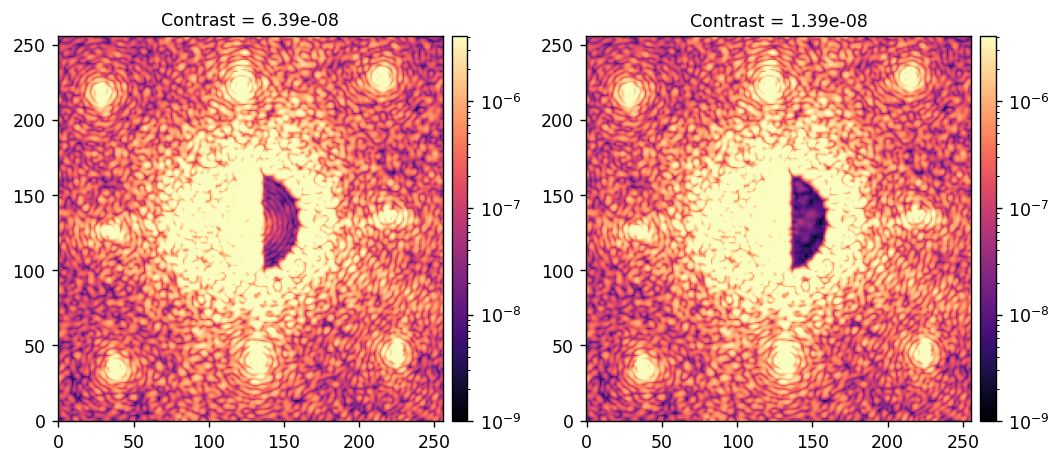

In [ ]:
camsci_ims = utils.load_fits(camsci_data_fnames[0])
contrasts = xp.mean(camsci_ims[:, control_mask], axis=1)

utils.imshow(
    [camsci_ims[0], camsci_ims[-5]],
    titles=[f'Contrast = {contrasts[0]:.2e}', f'Contrast = {contrasts[-5]:.2e}'],
    norms=[LogNorm(1e-9)]*2,
)


In [ ]:
time_steps = np.linspace(0, 10, time_series_ims.shape[1])




300